QUESTION NUMBER 9, PAGE 133, CHAPTER 15 OF THE TEXTBOOK "AN INTRODUCTION TO STATISTICAL LEARNING WITH APPLICATIONS IN PYTHON".

This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from ISLP import load_data

In [2]:
boston = load_data('Boston')
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


QUESTION A

For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

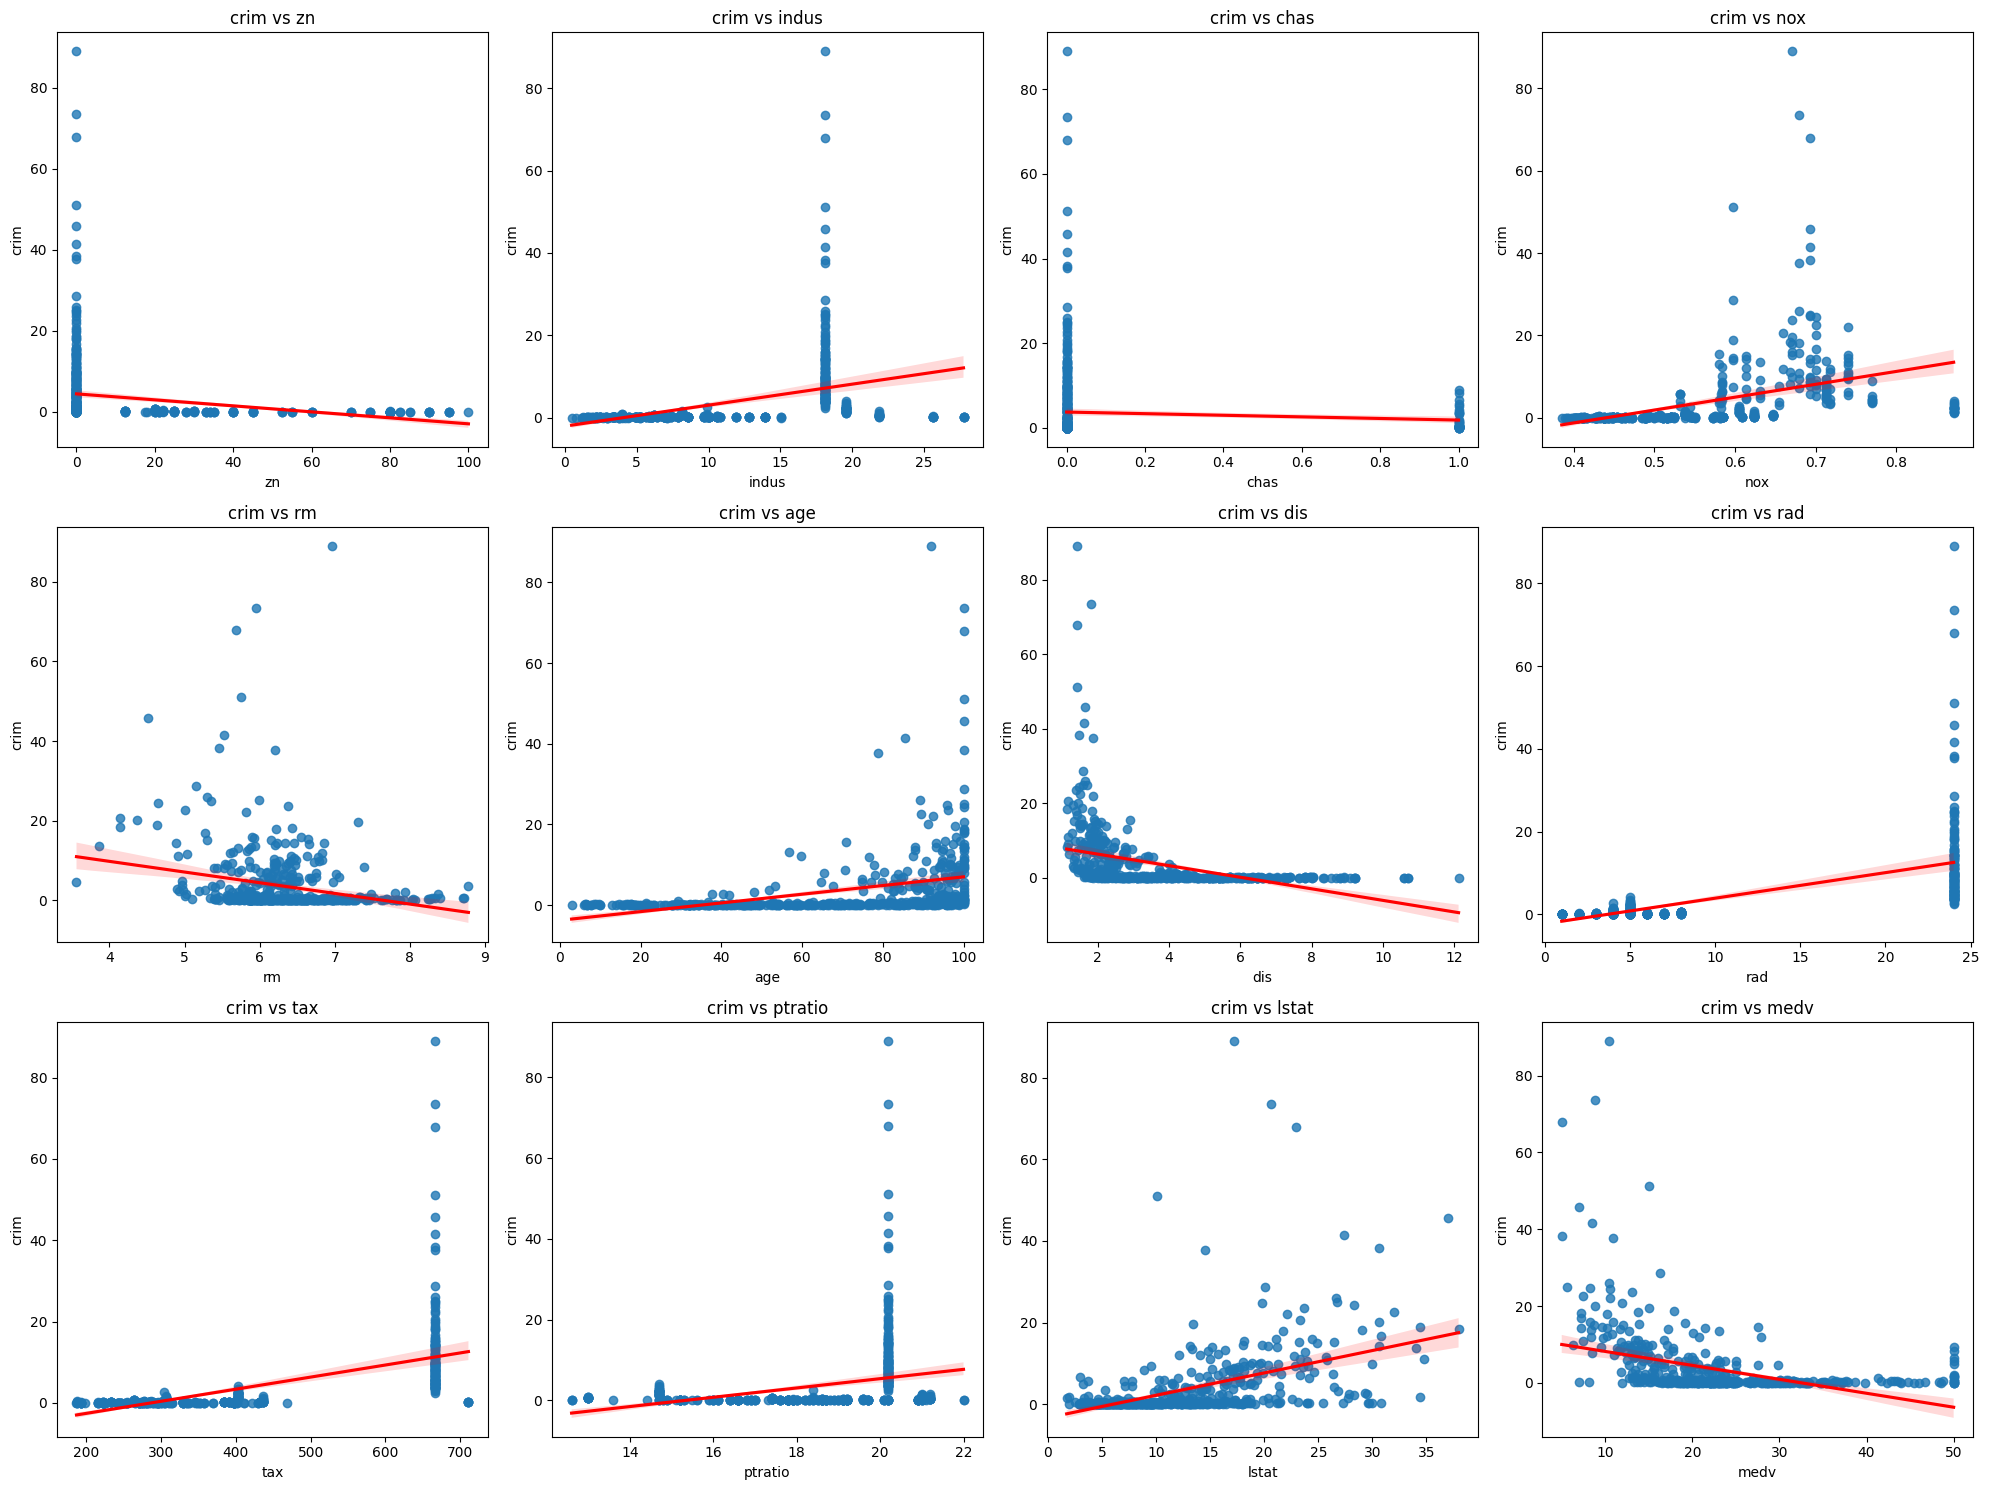

In [3]:
# Store results
results = []

# Set up 3x4 subplot grid
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
axs = axs.flatten()

# Loop through each predictor

for i, predictor in enumerate(boston.columns.drop('crim')):
    X = sm.add_constant(boston[predictor])
    y = boston['crim']
    model = sm.OLS(y, X).fit()
    
    coef = model.params[predictor]
    pval = model.pvalues[predictor]
    r2 = model.rsquared
    
    results.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'p-value': pval,
        'R²': r2
    })
    
    # Plot
    sns.regplot(x=predictor, y='crim', data=boston, ax=axs[i], line_kws={'color': 'red'})
    axs[i].set_title(f'crim vs {predictor}')
    axs[i].set_xlabel(predictor)
    axs[i].set_ylabel('crim')
plt.tight_layout()

# Remove unused subplot if < 12 predictors
for j in range(len(boston.columns.drop('crim')), len(axs)):
    fig.delaxes(axs[j])

In [4]:
# Create summary table
summary_boston = pd.DataFrame(results)
summary_boston = summary_boston.sort_values(by='p-value')
print(summary_boston)

   Predictor  Coefficient       p-value        R²
7        rad     0.617911  2.693844e-56  0.391257
8        tax     0.029742  2.357127e-47  0.339614
10     lstat     0.548805  2.654277e-27  0.207591
3        nox    31.248531  3.751739e-23  0.177217
1      indus     0.509776  1.450349e-21  0.165310
11      medv    -0.363160  1.173987e-19  0.150780
6        dis    -1.550902  8.519949e-19  0.144149
5        age     0.107786  2.854869e-16  0.124421
9    ptratio     1.151983  2.942922e-11  0.084068
4         rm    -2.684051  6.346703e-07  0.048069
0         zn    -0.073935  5.506472e-06  0.040188
2       chas    -1.892777  2.094345e-01  0.003124


All of the simple linear regression models have statistically significant influence on the 'crim' variable. 

1. The one that explain the crime rate the most is the 'rad' variable, which shows the index of accessibility to radial highways, meaning the higher the index, the more connected the house to Boston's highway infrastructure. From the coefficient, the p-value, and the R² of 'rad', the closer the house to the highway, the more crrimes happen in the area of the house.
Intuitive interpretation: We can say that in neighborhoods with greater access to highways and major roads have more crowd passing by and it is normal to see strangers come and go, because of higher traffic. Criminals can easily run away too. In neighborhoods with little access to highways or major roads will not have many strangers visit or pass by, and those who come are usually acquiantance or relatives. Hence, criminals or strangers that come into such neighborhood will stick out like a sore thumb, and will be a deterrent effect to criminals to do crimes.

2. 'tax' variable denotes full-value property tax rate per $10,000 in each suburb. A 'tax' value of 273 implies a tax of $273 per $10,000 of property value. Higher values suggest more expensive or aggressive local taxation policies.
Intuitive interpretation: Higher taxes are imposed on properties that have more values or more facilities or advantages (e.g., strategic position). It implies that those who can purchase a property with the higher taxes are the affluent ones, making the neighborhoods sensible targets for criminals.

3. 'lstat' variable denotes % of lower status population. Area with higher lower status population will have higher crime levels
intuitive interpretation: lower status neighborhood with have lower incomes, making crimes as a shortcut to make a living.

QUESTION B

Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0?

In [5]:
X = sm.add_constant(boston.drop('crim', axis = 1))
y = boston['crim']

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        22:16:00   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

We can reject the null hypothesis H0 : βj = 0 for those variables with p-values less than 0.05. These variables are significantly influencing the response variable 'crim'. Those variables are:
'zn', 'dis', 'rad', and 'medv'

QUESTION C

How do your results from (a) compare to your results from (b)? 
Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

When we apply multiple linear regression, we find that not all predictors significantly influence the response variable crim. This highlights an important distinction: a variable may appear impactful when considered in isolation, but its effect can diminish or shift when evaluated alongside other predictors. In other words, the influence of each variable depends not only on its individual relationship with the response, but also on how it interacts and overlaps with other variables in the model.

In [6]:
# Merging the simple linear regression coefficients and multiple linear regression coefficients
summary_boston = summary_boston.set_index('Predictor')
multi_df = results.params.drop('const').to_frame(name='Multiple Coef')
simple_df = summary_boston[['Coefficient']].rename(columns={'Coefficient': 'Simple Coef'})
merged = simple_df.join(multi_df)

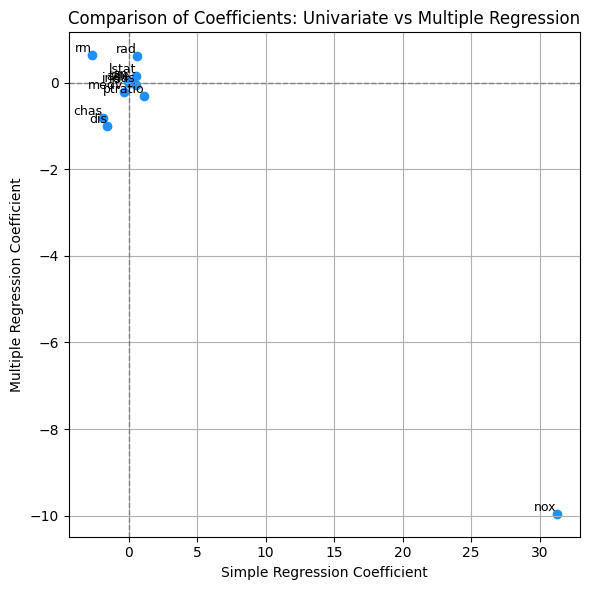

In [7]:
# Creating the scatterplot

plt.figure(figsize=(6, 6))
plt.scatter(merged.iloc[:, 0].values, merged.iloc[:, 1].values, color='dodgerblue')

# Add labels for each point
for i, predictor in enumerate(merged.index):
    x = merged.iloc[i, 0]
    y = merged.iloc[i, 1]
    plt.text(x, y, predictor, fontsize=9, ha='right', va='bottom')

# Optional: reference lines
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Simple Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Comparison of Coefficients: Univariate vs Multiple Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

The 'nox' variable has inconsistent values, showing the possibility of multicollinearity with other variables.

QUESTION D

Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form:
Y = β0 + β1X + β2X2 + β3X3 + ϵ.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly_results = []

for predictor in boston.columns.drop('crim'):
    X = boston[[predictor]]
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)
    X_poly = sm.add_constant(X_poly)
    
    y = boston['crim']
    model = sm.OLS(y, X_poly).fit()
    
    poly_results.append({
        'Predictor': predictor,
        'R²': model.rsquared,
        'p(X)': model.pvalues.iloc[1],
        'p(X²)': model.pvalues.iloc[2],
        'p(X³)': model.pvalues.iloc[3]
    })

poly_boston = pd.DataFrame(poly_results)
print(poly_boston.sort_values(by='R²', ascending=False))

   Predictor        R²          p(X)         p(X²)         p(X³)
11      medv  0.420200  2.637707e-28  3.260523e-18  1.046510e-12
7        rad  0.400037  6.234175e-01  6.130099e-01  4.823138e-01
8        tax  0.368882  1.097075e-01  1.374682e-01  2.438507e-01
3        nox  0.296978  2.758372e-13  6.811300e-15  6.961110e-16
6        dis  0.277825  6.374792e-18  4.941214e-12  1.088832e-08
1      indus  0.259658  5.297064e-05  3.420187e-10  1.196405e-12
10     lstat  0.217932  3.345300e-01  6.458736e-02  1.298906e-01
5        age  0.174231  1.426608e-01  4.737733e-02  6.679915e-03
9    ptratio  0.113782  3.028663e-03  4.119552e-03  6.300514e-03
4         rm  0.067786  2.117564e-01  3.641094e-01  5.085751e-01
0         zn  0.058242  2.612296e-03  9.375050e-02  2.295386e-01
2       chas  0.003121  6.813326e-01  6.813326e-01  6.813326e-01


Insight:
1. 'medv' and 'rad' have the highest explanatory power, but 'rad' are not significant on the first and second degree, suggesting that 'rad' variable' has non-linear relationship with 'crim'.
2. 'rm', 'zn', and 'chas' have the least explanatory power, and their p-values are mostly insignificant in every degree, suggesting that they do not influence 'crim'. We can drop these variables to make our model more accurate.